**LAB 04 : Linear Regression using TensorFlow with Inbuilt Dataset**

**Aim**

To implement Linear Regression using TensorFlow with an inbuilt dataset and evaluate model performance.

**Theory**

Linear Regression

Linear Regression predicts continuous output using:

y = Target value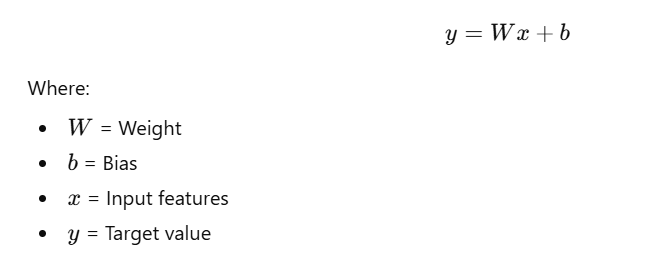

The model minimizes Mean Squared Error (MSE).

**Inbuilt Dataset Used**

We use:

California Housing Dataset

It contains:

8 input features

Median house value as output

Real-world housing data

**Software Requirements**

Google Colab

Python 3.x

TensorFlow 2.19

**Algorithm**

Import libraries

Load inbuilt dataset

Normalize data

Build regression model

Compile model

Train model

Evaluate model

Predict output

TensorFlow Version: 2.19.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediction for x = 7: [[15.246296]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


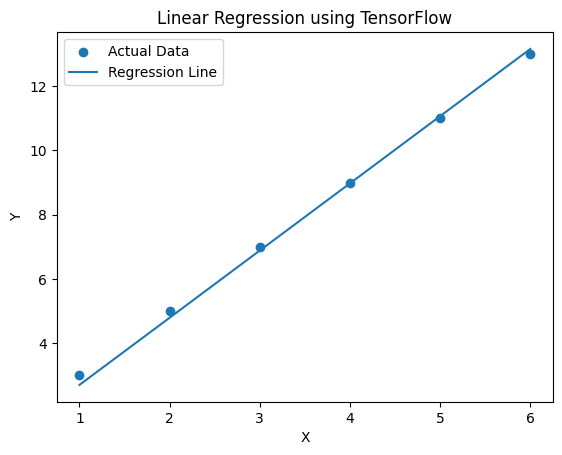

In [ ]:
# ==========================================
# LINEAR REGRESSION (TF 2.19 FIXED VERSION)
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# Dataset
X = np.array([1, 2, 3, 4, 5, 6], dtype=float)
Y = np.array([3, 5, 7, 9, 11, 13], dtype=float)

# Reshape for training
X = X.reshape(-1, 1)

# Model (Correct Input Layer)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

# Compile
model.compile(optimizer='sgd', loss='mean_squared_error')

# Train
model.fit(X, Y, epochs=200, verbose=0)

# Predict
prediction = model.predict(np.array([[7.0]]))
print("Prediction for x = 7:", prediction)

# Plot
plt.scatter(X, Y, label="Actual Data")
plt.plot(X, model.predict(X), label="Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Linear Regression using TensorFlow")
plt.show()


**With Dataset**

TensorFlow Version: 2.19.0
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5388 - mae: 0.5354
Test MSE: 0.5560503005981445
Test MAE: 0.5341074466705322


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


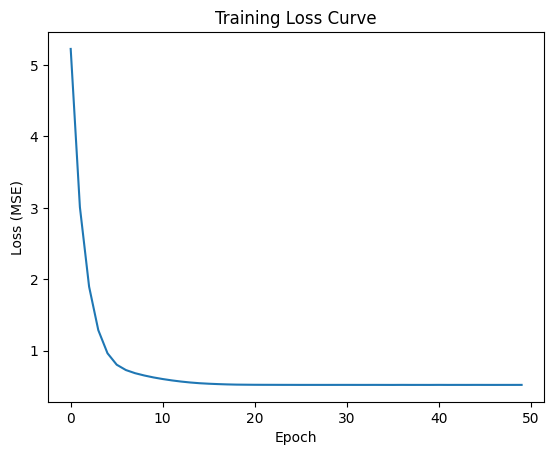

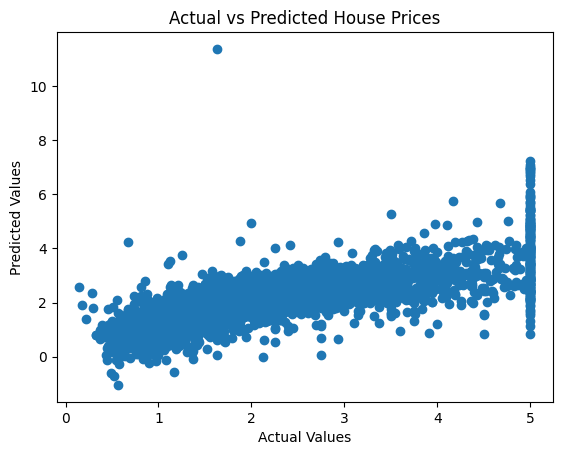

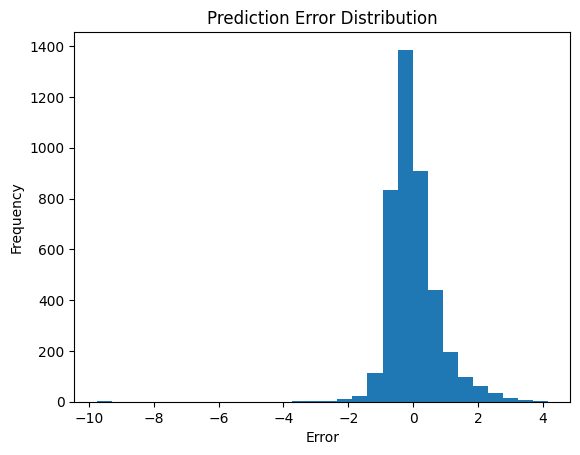

In [ ]:
# ==========================================
# LINEAR REGRESSION WITH VISUALIZATION
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("TensorFlow Version:", tf.__version__)

# Step 1: Load Dataset
housing = fetch_california_housing()
X = housing.data
Y = housing.target

# Step 2: Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Step 3: Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 4: Build Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(8,)),
    tf.keras.layers.Dense(1)
])

# Step 5: Compile
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Step 6: Train
history = model.fit(X_train, Y_train, epochs=50, verbose=0)

# Step 7: Evaluate
loss, mae = model.evaluate(X_test, Y_test)
print("Test MSE:", loss)
print("Test MAE:", mae)

# Step 8: Predictions
predictions = model.predict(X_test)

# ==============================
# VISUALIZATION SECTION
# ==============================

# 1️⃣ Loss Curve
plt.figure()
plt.plot(history.history['loss'])
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.show()

# 2️⃣ Actual vs Predicted Scatter Plot
plt.figure()
plt.scatter(Y_test, predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")
plt.show()

# 3️⃣ Error Distribution
errors = Y_test - predictions.flatten()
plt.figure()
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()
